# Section 3.2 and 3.3 Model Notebook
This notebook studies how government spending shocks affect a macroeconomy.

How to use this notebook:
1. Run cells from top to bottom.
2. First, build the baseline model and solve its steady state (Section 3.2).
3. Then compare model responses in low vs high productivity states (Section 3.3).

Big idea:
- Section 3.2 asks: "What happens after different government spending shocks?"
- Section 3.3 asks: "Do those effects change when productivity is low vs high?


## Parameters and Imports
This section loads libraries and sets the model's fixed numbers (parameters).

What these parameters mean in simple terms:
- `beta`: how patient households are (higher means more future-oriented).
- `sigma`: how strongly households dislike consumption fluctuations.
- `phi`: how responsive labor supply is to incentives.
- `alpha`: the share of output paid to capital.
- `delta`: how fast capital wears out each period.
- `z_sim`: productivity level used in Section 3.2 baseline run.
- Section 3.3 productivity states (`zL`, `zH`) are calibrated later from AR(1) parameters (`rho_z`, `sigma_eps`).
- `g_y_ratio`: normal government spending as a share of output.
- `shock_size`: size of the government spending shock.
- `T`: number of periods simulated after the shock.

These values act like the "settings" for the entire simulation.


In [ ]:
# Section 3.2 
import numpy as np
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

# 1. Parameters

# Household
beta  = 0.99
sigma = 2.0 #paper used 1
phi   = 1.0 

# Firm
alpha = 0.33
delta = 0.025

# Productivity state used for Section 3.2
z_sim = 1.0

# Government
g_y_ratio = 0.2          # baseline steady-state G/Y ratio
target_L  = 1.0 / 3.0    # calibrate chi so that L_ss = 1/3

# Shock settings
shock_size = 0.10        # 10% government spending shock
T = 40                   # simulation horizon
foreseen_shock_date = 5  # for scenario (1)


## Core Model Equations
This section defines the economy's basic production relationships.

Equations here do three jobs:
- `production_function`: turns capital (`K`) and labor (`L`) into output (`Y`) using productivity (`z`).
- `marginal_product_labor`: gives the real wage (`w`) from one extra unit of labor.
- `marginal_product_capital`: gives the return to capital (`rk`) from one extra unit of capital.

Intuition:
- Better productivity (`z`) raises output and tends to raise factor returns.
- More capital and labor usually increase output, but with diminishing marginal gains.


In [2]:
# 2. Core model equations

def production_function(K, L, z):
    return z * (K ** alpha) * (L ** (1 - alpha))

def marginal_product_labor(K, L, z):
    return (1 - alpha) * z * (K ** alpha) * (L ** (-alpha))

def marginal_product_capital(K, L, z):
    return alpha * z * (K ** (alpha - 1)) * (L ** (1 - alpha))


## Steady-State Calibration and Solver
This section finds the model's "normal" long-run point (steady state).

What happens step-by-step:
1. `calibrate_chi` chooses the labor disutility parameter `chi` so steady-state labor matches the target (`L = 1/3`).
2. `steady_state_fixed_G_equations` writes the three steady-state conditions:
   - Euler equation (intertemporal optimality),
   - labor first-order condition,
   - resource constraint (`Y = C + I + G`).
3. `solve_steady_state_fixed_G` uses `fsolve` to solve for steady-state `K`, `L`, and `C`.

Why this matters:
- All impulse responses are measured relative to this baseline.


In [3]:
# 3. Calibrate chi so that steady-state labor = 1/3

def calibrate_chi(z=1.0, L_target=1/3, K_guess=10.0):
    """
    Baseline calibration uses:
        G_ss = g_y_ratio * Y_ss

    Fix L = L_target, solve Euler equation for K,
    then back out chi from the labor FOC:
        chi * L^phi = w * C^(-sigma)
    """

    def euler_equation_for_K(K_array):
        K = K_array[0]

        if K <= 0:
            return [1e6]

        rk = marginal_product_capital(K, L_target, z)
        return [1.0 - beta * (rk + 1.0 - delta)]

    K_ss = fsolve(euler_equation_for_K, [K_guess])[0]

    Y_ss = production_function(K_ss, L_target, z)
    I_ss = delta * K_ss
    G_ss = g_y_ratio * Y_ss
    C_ss = Y_ss - I_ss - G_ss

    if C_ss <= 0:
        raise ValueError("Calibration failed: steady-state consumption is non-positive.")

    w_ss = marginal_product_labor(K_ss, L_target, z)
    chi_value = w_ss * (C_ss ** (-sigma)) / (L_target ** phi)

    return {
        "chi": chi_value,
        "K": K_ss,
        "L": L_target,
        "C": C_ss,
        "Y": Y_ss,
        "I": I_ss,
        "G": G_ss
    }

# 4. Solve steady state for a given fixed level of G

def steady_state_fixed_G_equations(vars, z, chi, G_fixed):
    """
    Unknowns: K, L, C

    Steady-state conditions:
        1 = beta * (rk + 1 - delta)
        chi * L^phi = w * C^(-sigma)
        Y = C + delta*K + G_fixed
    """
    K, L, C = vars

    if K <= 0 or L <= 0 or C <= 0:
        return [1e6, 1e6, 1e6]

    Y  = production_function(K, L, z)
    w  = marginal_product_labor(K, L, z)
    rk = marginal_product_capital(K, L, z)

    eq1 = 1.0 - beta * (rk + 1.0 - delta)
    eq2 = chi * (L ** phi) - w * (C ** (-sigma))
    eq3 = Y - C - delta * K - G_fixed

    return [eq1, eq2, eq3]


def solve_steady_state_fixed_G(z, chi, G_fixed, initial_guess=(10.0, 0.33, 1.0)):
    sol = fsolve(
        steady_state_fixed_G_equations,
        initial_guess,
        args=(z, chi, G_fixed)
    )

    K_ss, L_ss, C_ss = sol
    Y_ss  = production_function(K_ss, L_ss, z)
    I_ss  = delta * K_ss
    w_ss  = marginal_product_labor(K_ss, L_ss, z)
    rk_ss = marginal_product_capital(K_ss, L_ss, z)

    return {
        "K": K_ss,
        "L": L_ss,
        "C": C_ss,
        "Y": Y_ss,
        "I": I_ss,
        "G": G_fixed,
        "w": w_ss,
        "rk": rk_ss
    }


In [11]:
#4. Find baseline steady state

calib_results = calibrate_chi(z=z_sim, L_target=target_L)
chi = calib_results['chi']
ss_baseline = solve_steady_state_fixed_G(z_sim, chi, calib_results['G'])

print(f"Calibrated Chi: {chi:.4f}")
# Print the full baseline steady-state equilibrium
print("-" * 30)
print("BASELINE STEADY STATE (Section 3.2)")
print("-" * 30)

# Dictionary contains K, L, C, Y, I, G, w, and rk
for var_name, value in ss_baseline.items():
    # Format labels for better readability
    label = {
        'K': 'Capital (K)',
        'L': 'Labor (L)',
        'C': 'Consumption (C)',
        'Y': 'Output (Y)',
        'I': 'Investment (I)',
        'G': 'Gov Spending (G)',
        'w': 'Real Wage (w)',
        'rk': 'Return to Cap (rk)'
    }.get(var_name, var_name)
    
    print(f"{label:<18}: {value:.4f}")

Calibrated Chi: 18.7959
------------------------------
BASELINE STEADY STATE (Section 3.2)
------------------------------
Capital (K)       : 9.4495
Labor (L)         : 0.3333
Consumption (C)   : 0.5679
Output (Y)        : 1.0051
Investment (I)    : 0.2362
Gov Spending (G)  : 0.2010
Real Wage (w)     : 2.0203
Return to Cap (rk): 0.0351


## Transition Dynamics
Steady state is one snapshot. This section builds the full time path after a shock.

Main idea:
- Solve for sequences over time: consumption `C_t`, labor `L_t`, and next-period capital `K_{t+1}`.

How it works:
- `pack_transition_variables` / `unpack_transition_variables` convert between arrays and the vector format needed by `fsolve`.
- `transition_system` stacks all period-by-period conditions:
  - labor condition each period,
  - resource/capital accumulation each period,
  - Euler equations linking today and tomorrow,
  - final (terminal) capital condition.
- `solve_transition_path` solves this system and reconstructs paths for `K`, `C`, `L`, `Y`, and `I`.

Intuition:
- After a shock, the economy does not jump instantly to a new long-run point; it adjusts gradually.


In [4]:
# 5. Transition path solver (perfect foresight)

def pack_transition_variables(C_path, L_path, K_next_path):
    return np.concatenate([C_path, L_path, K_next_path])

def unpack_transition_variables(x, T):
    C_path      = x[0:T+1]
    L_path      = x[T+1:2*(T+1)]
    K_next_path = x[2*(T+1):3*(T+1)]
    return C_path, L_path, K_next_path


def transition_system(x, K0, z, chi, G_path, terminal_K):
    """
    Unknowns:
        C_t, L_t, K_{t+1}   for t = 0,...,T

    Equations:
        (i)   labor FOC, t=0,...,T
        (ii)  resource/capital accumulation, t=0,...,T
        (iii) Euler equation, t=0,...,T-1
        (iv)  terminal condition K_{T+1} = terminal_K
    """
    T = len(G_path) - 1
    C_path, L_path, K_next_path = unpack_transition_variables(x, T)

    eqs = []

    # 1. Labor FOC and resource constraint for each t
    for t in range(T + 1):
        K_t = K0 if t == 0 else K_next_path[t - 1]
        C_t = C_path[t]
        L_t = L_path[t]
        G_t = G_path[t]

        if K_t <= 0 or C_t <= 0 or L_t <= 0:
            return np.ones(3 * (T + 1)) * 1e6

        Y_t = production_function(K_t, L_t, z)
        w_t = marginal_product_labor(K_t, L_t, z)

        # labor FOC
        eq_labor = chi * (L_t ** phi) - w_t * (C_t ** (-sigma))
        eqs.append(eq_labor)

        # resource constraint + capital accumulation:
        # Y_t = C_t + G_t + K_{t+1} - (1-delta)K_t
        eq_resource = Y_t - C_t - G_t - (K_next_path[t] - (1.0 - delta) * K_t)
        eqs.append(eq_resource)

    # 2. Euler equations for t = 0,...,T-1
    for t in range(T):
        K_tp1 = K_next_path[t]
        C_t   = C_path[t]
        C_tp1 = C_path[t + 1]
        L_tp1 = L_path[t + 1]

        rk_tp1 = marginal_product_capital(K_tp1, L_tp1, z)

        eq_euler = (C_t ** (-sigma)) - beta * (C_tp1 ** (-sigma)) * (rk_tp1 + 1.0 - delta)
        eqs.append(eq_euler)

    # 3. Terminal condition on capital
    eq_terminal = K_next_path[T] - terminal_K
    eqs.append(eq_terminal)

    return np.array(eqs)


def solve_transition_path(K0, z, chi, G_path, initial_ss, terminal_ss):
    T = len(G_path) - 1

    # Initial guesses
    C_guess = np.linspace(initial_ss["C"], terminal_ss["C"], T + 1)
    L_guess = np.linspace(initial_ss["L"], terminal_ss["L"], T + 1)
    K_guess = np.linspace(initial_ss["K"], terminal_ss["K"], T + 1)

    x0 = pack_transition_variables(C_guess, L_guess, K_guess)

    sol = fsolve(
        transition_system,
        x0,
        args=(K0, z, chi, G_path, terminal_ss["K"]),
        xtol=1e-10,
        maxfev=50000
    )

    C_path, L_path, K_next_path = unpack_transition_variables(sol, T)

    # Build K_t path including initial K0
    K_path = np.zeros(T + 1)
    K_path[0] = K0
    for t in range(1, T + 1):
        K_path[t] = K_next_path[t - 1]

    Y_path = np.zeros(T + 1)
    I_path = np.zeros(T + 1)

    for t in range(T + 1):
        Y_path[t] = production_function(K_path[t], L_path[t], z)
        if t < T:
            I_path[t] = K_path[t + 1] - (1.0 - delta) * K_path[t]
        else:
            I_path[t] = K_next_path[T] - (1.0 - delta) * K_path[t]

    return {
        "K": K_path,
        "C": C_path,
        "L": L_path,
        "Y": Y_path,
        "I": I_path,
        "G": G_path
    }


## Government Spending Shock Paths
This section creates the three shock experiments required in Section 3.2.

1. `make_foreseen_one_time_G_path`
- One temporary increase in `G`, announced in advance at a future date.

2. `make_unforeseen_one_time_G_path`
- One temporary increase in `G` that hits unexpectedly at time 0.

3. `make_permanent_G_path`
- An unexpected increase in `G` at time 0 that stays permanently.

Why we separate them:
- Timing and expectations matter in macro models, so each path can produce different responses.


In [5]:
# 6. Government spending paths for Section 3.2

def make_foreseen_one_time_G_path(G_ss, shock_size, T, shock_date):
    G_path = np.full(T + 1, G_ss)
    G_path[shock_date] = G_ss * (1.0 + shock_size)
    return G_path

def make_unforeseen_one_time_G_path(G_ss, shock_size, T):
    G_path = np.full(T + 1, G_ss)
    G_path[0] = G_ss * (1.0 + shock_size)
    return G_path

def make_permanent_G_path(G_ss, shock_size, T):
    G_path = np.full(T + 1, G_ss * (1.0 + shock_size))
    return G_path


## Plotting Utilities
These helper functions turn raw simulation output into readable figures.

- `percent_deviation`: converts each variable path into percentage deviation from steady state.
- `plot_irfs`: draws impulse response graphs for six variables:
  - Consumption (`C`), Labor (`L`), Investment (`I`), Output (`Y`), Capital (`K`), Government spending (`G`).

How to read the plots:
- 0% line means "back at steady state".
- Positive values mean above normal; negative values mean below normal.


In [6]:
# 7. Plotting

def percent_deviation(path, steady_value):
    return 100.0 * (path - steady_value) / steady_value

def plot_irfs(results, baseline_ss, title):
    tgrid = np.arange(len(results["C"]))

    fig, axes = plt.subplots(3, 2, figsize=(12, 10))
    axes = axes.flatten()

    series = [
        ("Consumption", results["C"], baseline_ss["C"]),
        ("Labor",       results["L"], baseline_ss["L"]),
        ("Investment",  results["I"], baseline_ss["I"]),
        ("Output",      results["Y"], baseline_ss["Y"]),
        ("Capital",     results["K"], baseline_ss["K"]),
        ("Government",  results["G"], baseline_ss["G"]),
    ]

    for ax, (name, path, ss_val) in zip(axes, series):
        ax.plot(tgrid, percent_deviation(path, ss_val))
        ax.axhline(0.0, linewidth=0.8)
        ax.set_title(name)
        ax.set_xlabel("Time")
        ax.set_ylabel("% dev. from SS")

    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    plt.show()


## Section 3.2 Run
This cell executes the baseline experiment for one productivity level (`z_sim = 1.0`).

Workflow in this run:
1. Calibrate `chi` and compute baseline steady state.
2. Build the three government shock paths.
3. Set terminal conditions:
   - temporary shocks return to original steady state,
   - permanent shock converges to a new steady state with higher `G`.
4. Solve transition paths for each shock.
5. Plot IRFs.

This directly answers the Section 3.2 question.


Baseline Steady State:
Labor (L): 0.3333
Capital (K): 9.4495
Consumption (C): 0.5679
Output (Y): 1.0051
Government Spending (G): 0.2010



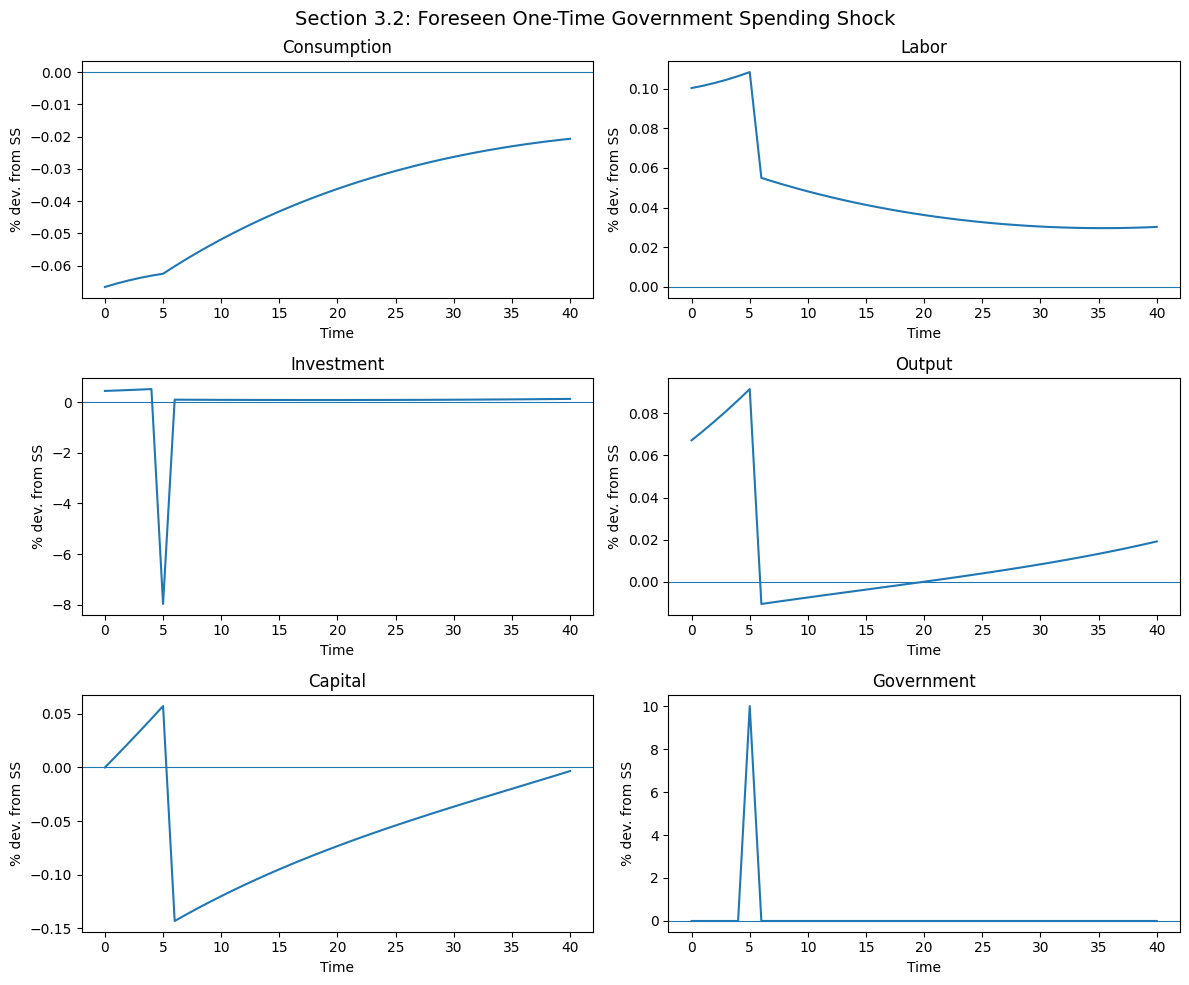

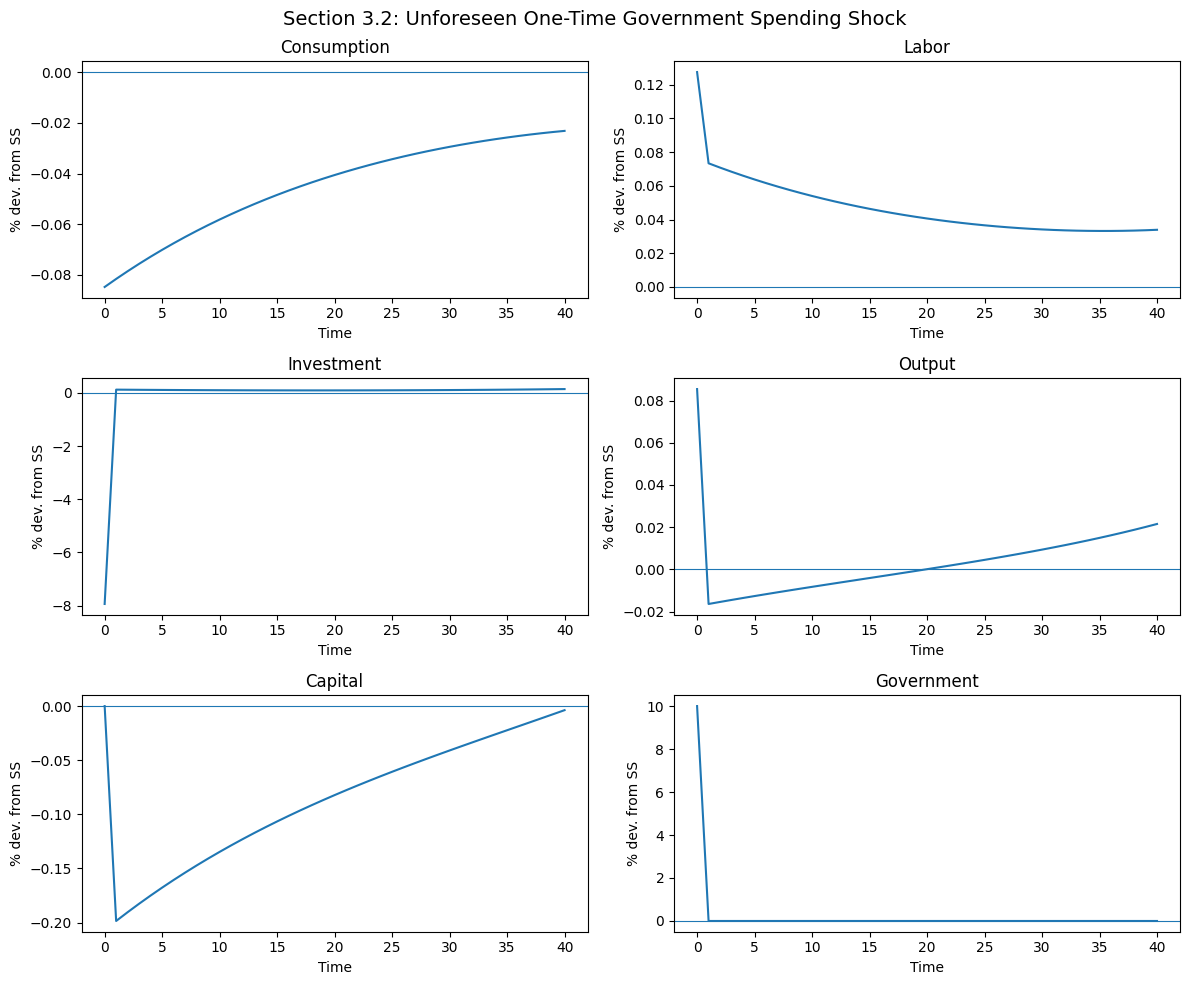

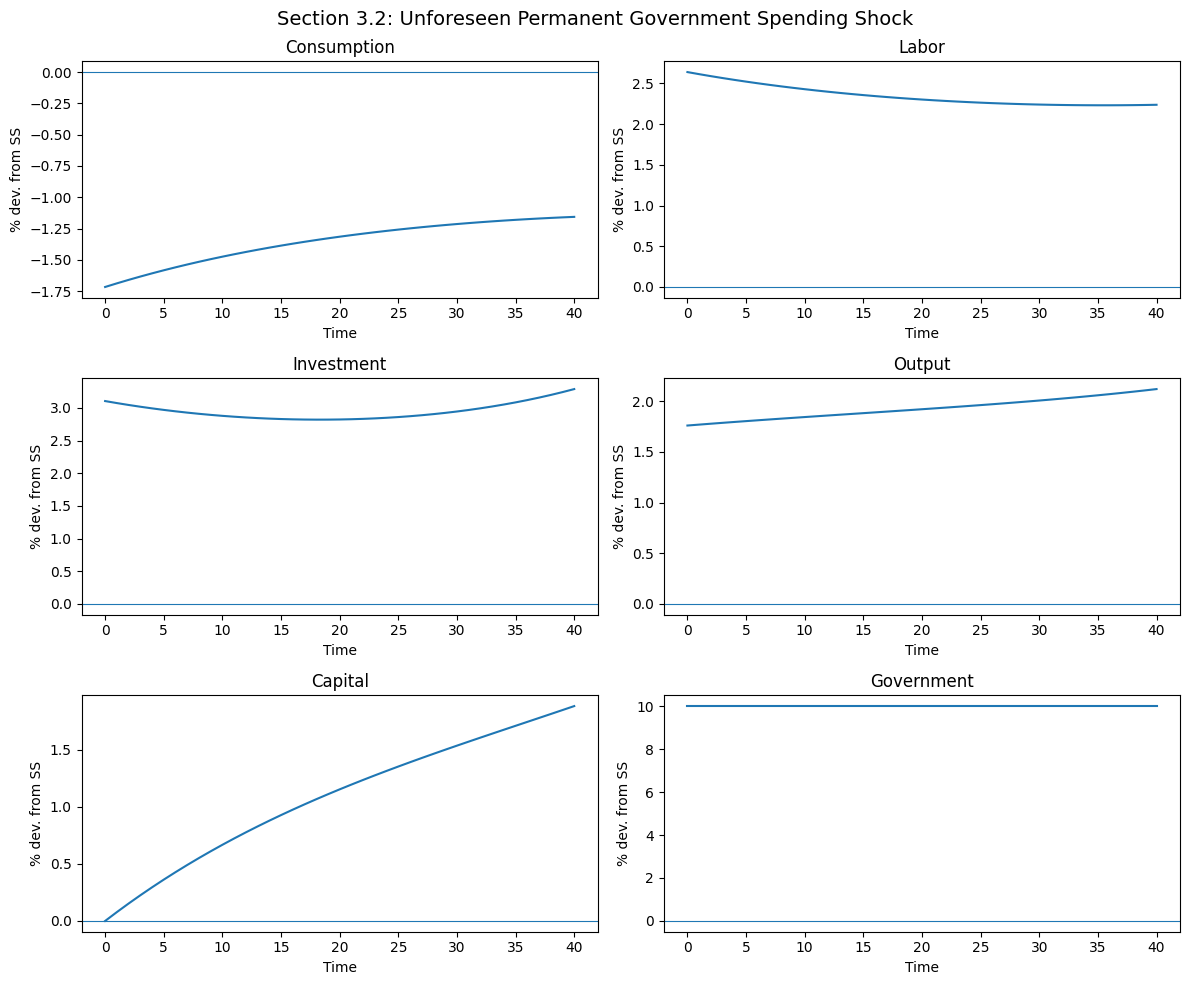

In [ ]:
# 8. Main: Section 3.2

if __name__ == "__main__":

    # Step A: REPLACED LOCAL CALIBRATION
    # We use the global variables 'chi' and 'ss_baseline' from Cell 7
    
    print("Using Globally Calibrated Steady State:")
    print(f"Labor (L): {ss_baseline['L']:.4f}")
    print(f"Capital (K): {ss_baseline['K']:.4f}")
    print(f"Consumption (C): {ss_baseline['C']:.4f}")
    print(f"Output (Y): {ss_baseline['Y']:.4f}")
    print(f"Government Spending (G): {ss_baseline['G']:.4f}")
    print()

    # Step B: build the three G paths

    # (1) Foreseen one-time shock at t = foreseen_shock_date
    G_path_foreseen = make_foreseen_one_time_G_path(
        G_ss=baseline_ss["G"],
        shock_size=shock_size,
        T=T,
        shock_date=foreseen_shock_date
    )

    # (2) Unforeseen one-time shock at t = 0
    G_path_unforeseen = make_unforeseen_one_time_G_path(
        G_ss=baseline_ss["G"],
        shock_size=shock_size,
        T=T
    )

    # (3) Unforeseen permanent shock from t = 0 onward
    G_path_permanent = make_permanent_G_path(
        G_ss=baseline_ss["G"],
        shock_size=shock_size,
        T=T
    )

    # Step C: terminal steady states

    # temporary shocks return to original steady state
    terminal_ss_temporary = baseline_ss

    # permanent shock converges to a new steady state with higher G
    G_perm = baseline_ss["G"] * (1.0 + shock_size)
    permanent_ss = solve_steady_state_fixed_G(
        z=z_sim,
        chi=chi,
        G_fixed=G_perm,
        initial_guess=(baseline_ss["K"], baseline_ss["L"], baseline_ss["C"])
    )

    # Step D: solve transition paths

    results_foreseen = solve_transition_path(
        K0=baseline_ss["K"],
        z=z_sim,
        chi=chi,
        G_path=G_path_foreseen,
        initial_ss=baseline_ss,
        terminal_ss=terminal_ss_temporary
    )

    results_unforeseen = solve_transition_path(
        K0=baseline_ss["K"],
        z=z_sim,
        chi=chi,
        G_path=G_path_unforeseen,
        initial_ss=baseline_ss,
        terminal_ss=terminal_ss_temporary
    )

    results_permanent = solve_transition_path(
        K0=baseline_ss["K"],
        z=z_sim,
        chi=chi,
        G_path=G_path_permanent,
        initial_ss=baseline_ss,
        terminal_ss=permanent_ss
    )

    # Step E: plot IRFs
    plot_irfs(results_foreseen, baseline_ss, "Section 3.2: Foreseen One-Time Government Spending Shock")
    plot_irfs(results_unforeseen, baseline_ss, "Section 3.2: Unforeseen One-Time Government Spending Shock")
    plot_irfs(results_permanent, baseline_ss, "Section 3.2: Unforeseen Permanent Government Spending Shock")


## Section 3.3 Helper (QuantEcon-Friendly)
This section builds a reusable 3.3 workflow without changing Section 3.2 code.

What is added here:
- optional QuantEcon import for state/Markov-chain context,
- the same three government-shock experiments, run conditionally at a chosen productivity state,
- a clean return object for plotting and comparison.

Important:
- If `quantecon` is not installed, the code still runs using the existing NumPy/SciPy setup.
- The core model equations and Section 3.2 logic remain unchanged.


In [8]:
# Section 3.3 helper: run the same 3.2 experiment conditional on one productivity state

# Optional QuantEcon support (safe fallback if unavailable)
try:
    import quantecon as qe
    HAS_QE = True
except Exception:
    HAS_QE = False

# Example transition matrix for productivity states (used for context in 3.3)
# Rows: current state, Columns: next state
# State order here is [zH, zL]
# This aligns with rho_z = 0.95 used later in the 3.3 calibration cell.
P_z = np.array([
    [0.95, 0.05],
    [0.05, 0.95]
])


def run_state_experiment(z_value, state_label):
    calibration = calibrate_chi(z=z_value, L_target=target_L, K_guess=10.0)
    chi = calibration["chi"]

    baseline_ss = solve_steady_state_fixed_G(
        z=z_value,
        chi=chi,
        G_fixed=calibration["G"],
        initial_guess=(calibration["K"], calibration["L"], calibration["C"])
    )

    G_path_foreseen = make_foreseen_one_time_G_path(
        G_ss=baseline_ss["G"],
        shock_size=shock_size,
        T=T,
        shock_date=foreseen_shock_date
    )

    G_path_unforeseen = make_unforeseen_one_time_G_path(
        G_ss=baseline_ss["G"],
        shock_size=shock_size,
        T=T
    )

    G_path_permanent = make_permanent_G_path(
        G_ss=baseline_ss["G"],
        shock_size=shock_size,
        T=T
    )

    terminal_ss_temporary = baseline_ss

    G_perm = baseline_ss["G"] * (1.0 + shock_size)
    permanent_ss = solve_steady_state_fixed_G(
        z=z_value,
        chi=chi,
        G_fixed=G_perm,
        initial_guess=(baseline_ss["K"], baseline_ss["L"], baseline_ss["C"])
    )

    results_foreseen = solve_transition_path(
        K0=baseline_ss["K"],
        z=z_value,
        chi=chi,
        G_path=G_path_foreseen,
        initial_ss=baseline_ss,
        terminal_ss=terminal_ss_temporary
    )

    results_unforeseen = solve_transition_path(
        K0=baseline_ss["K"],
        z=z_value,
        chi=chi,
        G_path=G_path_unforeseen,
        initial_ss=baseline_ss,
        terminal_ss=terminal_ss_temporary
    )

    results_permanent = solve_transition_path(
        K0=baseline_ss["K"],
        z=z_value,
        chi=chi,
        G_path=G_path_permanent,
        initial_ss=baseline_ss,
        terminal_ss=permanent_ss
    )

    print(f"\nState: {state_label} (z = {z_value:.2f})")
    print(f"L: {baseline_ss['L']:.4f}, K: {baseline_ss['K']:.4f}, C: {baseline_ss['C']:.4f}, I: {baseline_ss['I']:.4f}, Y: {baseline_ss['Y']:.4f}")

    return {
        "z": z_value,
        "label": state_label,
        "baseline_ss": baseline_ss,
        "results": {
            "foreseen": results_foreseen,
            "unforeseen": results_unforeseen,
            "permanent": results_permanent,
        }
    }


## Section 3.3 Run (Low vs High Productivity)
This section calibrates state values from an AR(1) log-productivity process:
- `log z_t = rho * log z_{t-1} + eps_t`, with `eps_t ~ N(0, sigma_eps^2)`.

Baseline choices used here:
- `rho = 0.95`
- `sigma_eps = 0.01`

Then stationary log standard deviation is:
- `sigma_log_z = sigma_eps / sqrt(1 - rho^2)`

We map this to two symmetric level states:
- `zL = exp(-sigma_log_z)`
- `zH = exp(+sigma_log_z)`

This gives approximately `zL ≈ 0.97`, `zH ≈ 1.03`.


In [9]:
# Section 3.3: compare low- and high-productivity states

# AR(1) calibration for log productivity
rho_z = 0.95
sigma_eps = 0.01  # shock std. dev. for epsilon_t in log productivity

sigma_log_z = sigma_eps / np.sqrt(1.0 - rho_z**2)

# Symmetric two-state approximation in levels
z_H = float(np.exp(+sigma_log_z))
z_L = float(np.exp(-sigma_log_z))

print(f"Using rho = {rho_z:.2f}, sigma_eps = {sigma_eps:.3f}")
print(f"Stationary log std. dev. = {sigma_log_z:.4f}")
print(f"Symmetric states -> zL = {z_L:.3f}, zH = {z_H:.3f}")

# Optional state-context summary via QuantEcon
if HAS_QE:
    mc = qe.MarkovChain(P_z, state_values=np.array(["zH", "zL"]))
    pi = mc.stationary_distributions[0]
    print("QuantEcon Markov chain loaded.")
    print("State order:", mc.state_values)
    print(f"Stationary probabilities -> zH: {pi[0]:.3f}, zL: {pi[1]:.3f}")
else:
    print("QuantEcon not installed; running 3.3 with NumPy/SciPy only.")

# Run 3.3 experiments
exp_low = run_state_experiment(z_L, "Low productivity")
exp_high = run_state_experiment(z_H, "High productivity")


# Optional: non-symmetric alternative (keep mean level near 1)
# If you want to fix zH manually and back out zL using stationary probabilities:
#   pi_H, pi_L = 0.5, 0.5   # or from Markov chain if available
#   zH_alt = 1.04
#   zL_alt = (1.0 - pi_H * zH_alt) / pi_L
# This ensures E[z] = pi_H*zH_alt + pi_L*zL_alt = 1.



Using rho = 0.95, sigma_eps = 0.010
Stationary log std. dev. = 0.0320
Symmetric states -> zL = 0.968, zH = 1.033
QuantEcon Markov chain loaded.
State order: ['zH' 'zL']
Stationary probabilities -> zH: 0.500, zL: 0.500

State: Low productivity (z = 0.97)
L: 0.3333, K: 9.0084, C: 0.5413, I: 0.2252, Y: 0.9582

State: High productivity (z = 1.03)
L: 0.3333, K: 9.9121, C: 0.5957, I: 0.2478, Y: 1.0543


## Section 3.3 Comparison Plots
These plots compare the four required variables from the question:
- Consumption (`C`)
- Labor supply (`L`)
- Investment (`I`)
- Output (`Y`)

Interpretation tip:
- Solid line: low productivity (`zL`)
- Dashed line: high productivity (`zH`)
- Vertical differences show state dependence of fiscal shock transmission.


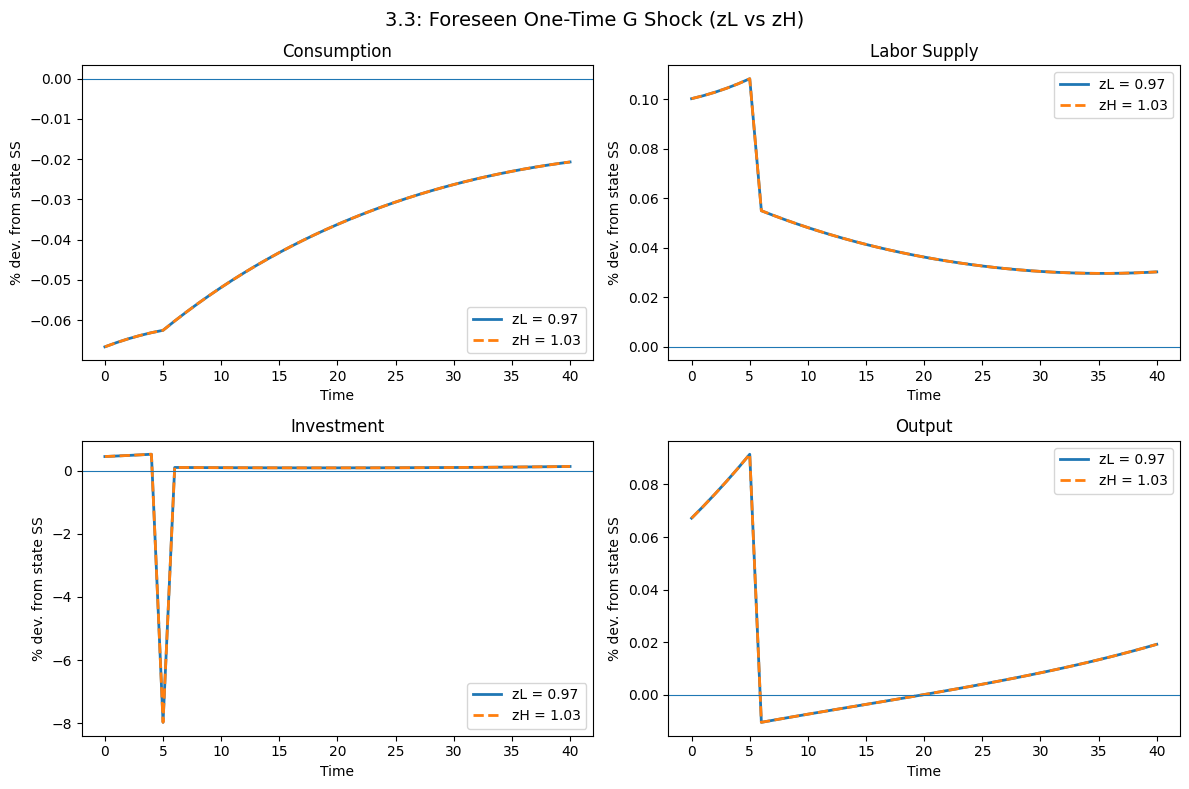

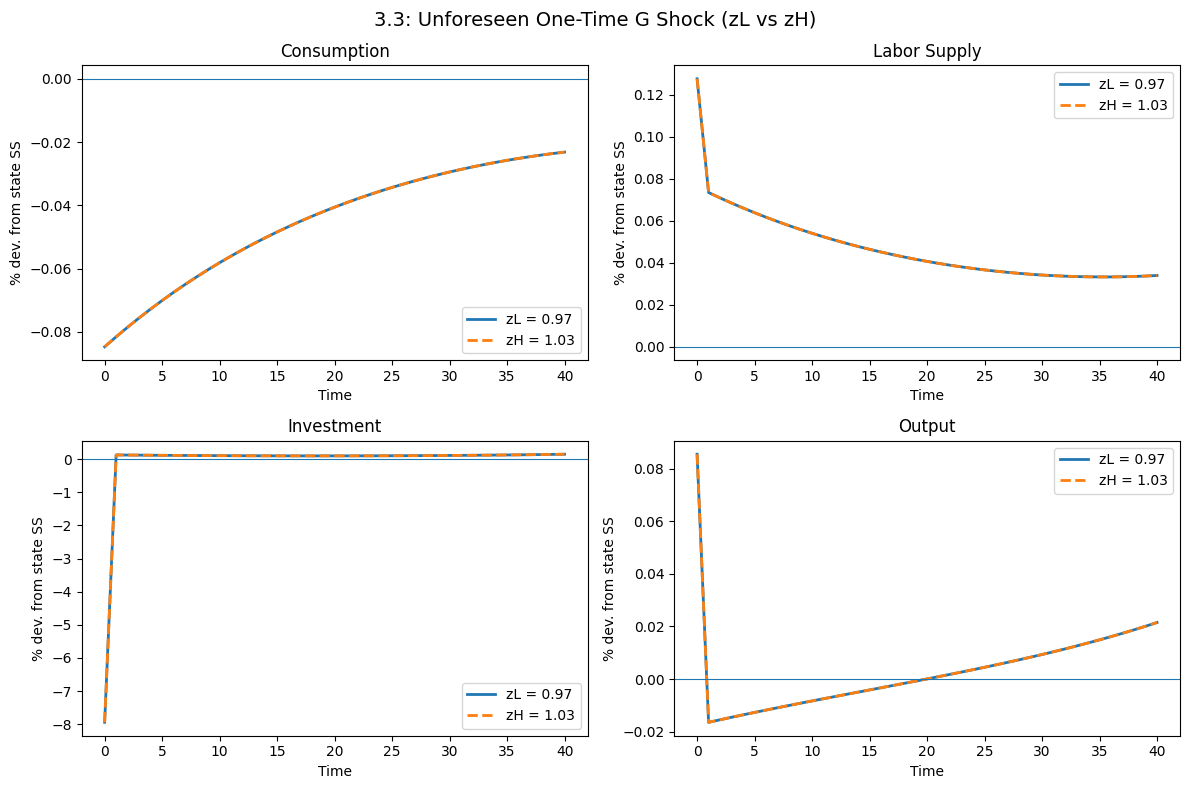

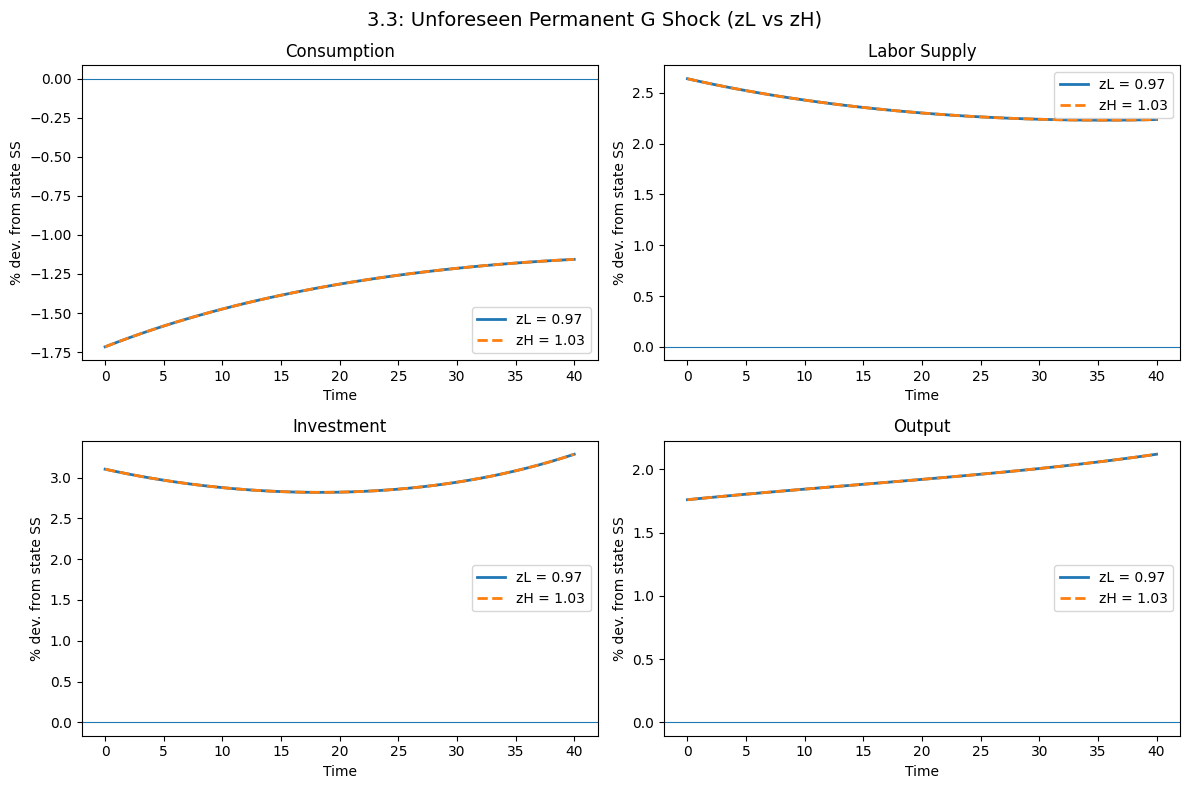

In [10]:
# Section 3.3 plots: C, L, I, Y responses under zL vs zH for each G-shock

def plot_state_comparison(exp_low, exp_high, shock_key, shock_title):
    tgrid = np.arange(T + 1)

    vars_to_plot = [
        ("C", "Consumption"),
        ("L", "Labor Supply"),
        ("I", "Investment"),
        ("Y", "Output"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for ax, (var, var_name) in zip(axes, vars_to_plot):
        low_dev = percent_deviation(exp_low["results"][shock_key][var], exp_low["baseline_ss"][var])
        high_dev = percent_deviation(exp_high["results"][shock_key][var], exp_high["baseline_ss"][var])

        ax.plot(tgrid, low_dev, label=f"zL = {exp_low['z']:.2f}", linewidth=2)
        ax.plot(tgrid, high_dev, label=f"zH = {exp_high['z']:.2f}", linewidth=2, linestyle='--')
        ax.axhline(0.0, linewidth=0.8)
        ax.set_title(var_name)
        ax.set_xlabel("Time")
        ax.set_ylabel("% dev. from state SS")
        ax.legend()

    fig.suptitle(shock_title, fontsize=14)
    fig.tight_layout()
    plt.show()


plot_state_comparison(exp_low, exp_high, "foreseen", "3.3: Foreseen One-Time G Shock (zL vs zH)")
plot_state_comparison(exp_low, exp_high, "unforeseen", "3.3: Unforeseen One-Time G Shock (zL vs zH)")
plot_state_comparison(exp_low, exp_high, "permanent", "3.3: Unforeseen Permanent G Shock (zL vs zH)")

